# Notebook 4: Experiment Tracking with MLflow

In this notebook, we track machine learning experiments using MLflow.

Notebook 1 focused on EDA.
Notebook 2 focused on feature engineering and model training.
Notebook 3 focused on model validation and final model selection.

Now, this notebook records model parameters, evaluation metrics, plots, and trained models so that experiments are reproducible and easy to compare.

In [15]:
import mlflow
import mlflow.sklearn

# Store MLflow experiments in the project root so both the notebook
# and the MLflow UI use the same tracking database.

mlflow.set_tracking_uri("sqlite:///../mlflow.db")
mlflow.set_experiment("heart_disease_experiment_tracking")

print("MLflow version:", mlflow.__version__)

MLflow version: 3.14.0


In [16]:
print("Tracking URI:", mlflow.get_tracking_uri())

Tracking URI: sqlite:///../mlflow.db


# Import Libraries

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

In [18]:
data_path = "../data/processed/heart_cleaned.csv"

df = pd.read_csv(data_path)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [19]:
df.shape

(303, 14)

In [20]:
X = df.drop("target", axis=1)
y = df["target"]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [22]:
mlflow.set_experiment("heart_disease_experiment_tracking")

<Experiment: artifact_location='file:d:/MLOps/heart-disease-mlops/notebooks/mlruns/1', creation_time=1783616492469, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1783616492469, lifecycle_stage='active', name='heart_disease_experiment_tracking', tags={}, trace_location=None, workspace='default'>

# Create folder for MLflow plots

In [23]:
import os

plots_dir = "../reports/mlflow_plots"
os.makedirs(plots_dir, exist_ok=True)

print("Plots will be saved in:", plots_dir)

Plots will be saved in: ../reports/mlflow_plots


# Creat Model Dictionary

In [24]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        random_state=42
    )
}

# Creat MLFLOW training function

In [25]:
def train_and_log_model(model_name, model):
    with mlflow.start_run(run_name=model_name):
        
        pipeline = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", model)
        ])
        
        pipeline.fit(X_train, y_train)
        
        y_pred = pipeline.predict(X_test)
        y_proba = pipeline.predict_proba(X_test)[:, 1]
        
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_proba)
        
        mlflow.log_param("model_name", model_name)
        mlflow.log_param("test_size", 0.2)
        mlflow.log_param("random_state", 42)
        mlflow.log_param("imputer_strategy", "median")
        mlflow.log_param("scaler", "StandardScaler")
        
        mlflow.log_metric("accuracy", accuracy)
        mlflow.log_metric("precision", precision)
        mlflow.log_metric("recall", recall)
        mlflow.log_metric("f1_score", f1)
        mlflow.log_metric("roc_auc", roc_auc)
        
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot()
        plt.title(f"Confusion Matrix - {model_name}")
        cm_path = os.path.join(plots_dir, f"{model_name}_confusion_matrix.png")
        plt.savefig(cm_path, bbox_inches="tight")
        plt.show()
        mlflow.log_artifact(cm_path)
        
        RocCurveDisplay.from_predictions(y_test, y_proba)
        plt.title(f"ROC Curve - {model_name}")
        roc_path = os.path.join(plots_dir, f"{model_name}_roc_curve.png")
        plt.savefig(roc_path, bbox_inches="tight")
        plt.show()
        mlflow.log_artifact(roc_path)
        
        mlflow.sklearn.log_model(
        sk_model=pipeline,
        artifact_path="model",
        serialization_format="pickle"
        )
        
        print(f"Completed MLflow run for: {model_name}")
        print("Accuracy:", accuracy)
        print("Precision:", precision)
        print("Recall:", recall)
        print("F1-score:", f1)
        print("ROC-AUC:", roc_auc)
        
        return {
            "model_name": model_name,
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1_score": f1,
            "roc_auc": roc_auc
        }

# Run Both Experiments

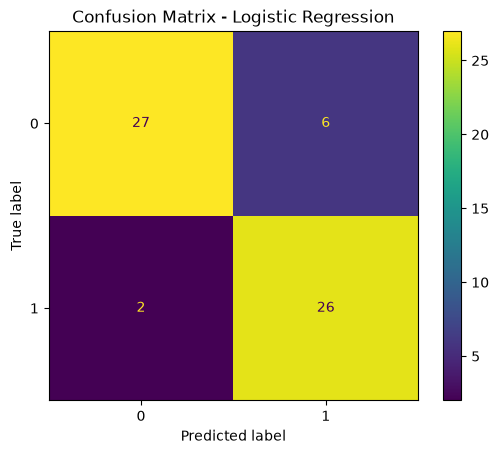

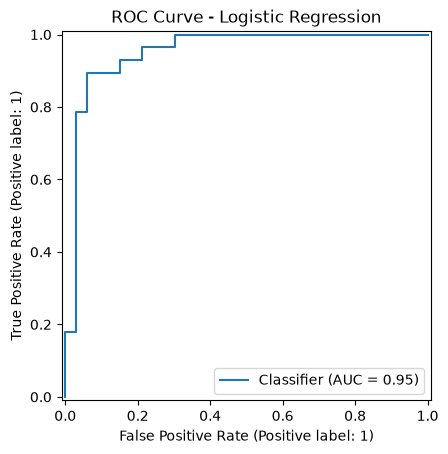

2026/07/09 23:01:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/09 23:01:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Completed MLflow run for: Logistic Regression
Accuracy: 0.8688524590163934
Precision: 0.8125
Recall: 0.9285714285714286
F1-score: 0.8666666666666667
ROC-AUC: 0.9512987012987013


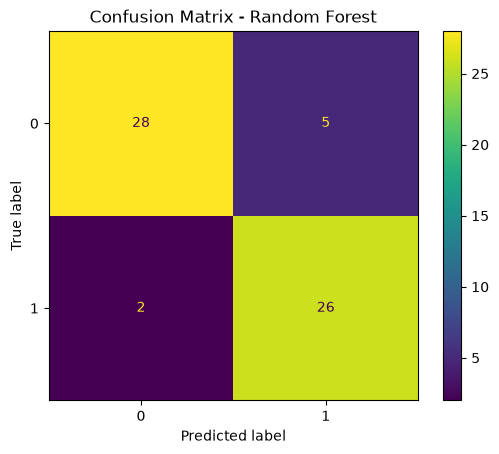

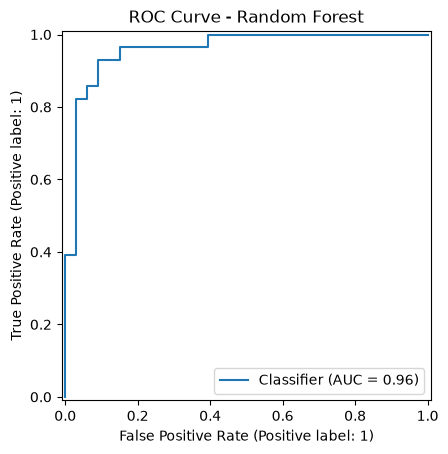

2026/07/09 23:01:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/09 23:01:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Completed MLflow run for: Random Forest
Accuracy: 0.8852459016393442
Precision: 0.8387096774193549
Recall: 0.9285714285714286
F1-score: 0.8813559322033898
ROC-AUC: 0.9588744588744589


In [26]:
results = []

for model_name, model in models.items():
    result = train_and_log_model(model_name, model)
    results.append(result)

# Creat Result Table

In [27]:
results_df = pd.DataFrame(results)

results_df

,model_name,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.868852,0.81250,0.928571,0.866667,0.951299
1,Random Forest,0.885246,0.83871,0.928571,0.881356,0.958874


## Experiment Summary

Two machine learning models were tracked using MLflow.

Both models achieved excellent ROC-AUC values (>0.95), indicating strong discriminative performance.

Random Forest achieved the highest Accuracy (88.52%), Precision (83.87%), F1-score (88.14%), and ROC-AUC (95.89%).

Therefore, Random Forest is selected as the best model for subsequent packaging and deployment.